In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

!pip install scikit-learn
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Set display options to show all columns
pd.set_option('display.max_columns', None)

In [ ]:
# mount your google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/OPIM 5604/listings.csv')

#Columns 1 - 20

*After review of this block of columns we keep

 id and host_id

In [ ]:
selected_columns = df.columns[0:20]
df_slice1_20 = df[selected_columns]

print(f"Original DataFrame shape: {df.shape}")
print(f"Selected DataFrame shape: {df.shape}")
print("First 5 rows of the selected columns:")
print(df_slice1_20.head())

Original DataFrame shape: (7444, 79)
Selected DataFrame shape: (7444, 79)
First 5 rows of the selected columns:
      id                         listing_url       scrape_id last_scraped  \
0  19091  https://www.airbnb.com/rooms/19091  20250911031349   2025-09-11   
1  71624  https://www.airbnb.com/rooms/71624  20250911031349   2025-09-11   
2  74498  https://www.airbnb.com/rooms/74498  20250911031349   2025-09-11   
3  79536  https://www.airbnb.com/rooms/79536  20250911031349   2025-09-11   
4  79609  https://www.airbnb.com/rooms/79609  20250911031349   2025-09-11   

            source                                name  \
0      city scrape      Fully Furnished Cozy Apartment   
1      city scrape  Ravenwood Manor (Historic Bywater)   
2      city scrape                     Maison Marais 1   
3  previous scrape   FeelAtHomeInNewOrleans-PrivateApt   
4      city scrape         Bywater's Original & Finest   

                                         description  \
0  This cozy space i

In [ ]:
selected_columns = df.columns[0:20].tolist()
# Insert 'price' at index 1 (second position)
selected_columns.insert(1, 'price')

# Create the new DataFrame with the desired column order
df_slice_price1_20 = df[selected_columns]

print(f"Original DataFrame shape: {df.shape}")
print(f"Selected DataFrame shape: {df_slice1_20.shape}")
print("First 5 rows of the selected columns:")
print(df_slice_price1_20.head())

Original DataFrame shape: (7444, 79)
Selected DataFrame shape: (7444, 20)
First 5 rows of the selected columns:
      id    price                         listing_url       scrape_id  \
0  19091   $61.00  https://www.airbnb.com/rooms/19091  20250911031349   
1  71624  $150.00  https://www.airbnb.com/rooms/71624  20250911031349   
2  74498   $85.00  https://www.airbnb.com/rooms/74498  20250911031349   
3  79536      NaN  https://www.airbnb.com/rooms/79536  20250911031349   
4  79609   $84.00  https://www.airbnb.com/rooms/79609  20250911031349   

  last_scraped           source                                name  \
0   2025-09-11      city scrape      Fully Furnished Cozy Apartment   
1   2025-09-11      city scrape  Ravenwood Manor (Historic Bywater)   
2   2025-09-11      city scrape                     Maison Marais 1   
3   2025-09-11  previous scrape   FeelAtHomeInNewOrleans-PrivateApt   
4   2025-09-11      city scrape         Bywater's Original & Finest   

                      

In [ ]:
print("Missing values per column in df_slice_price1_20:")
print(df_slice_price1_20.isnull().sum())

Missing values per column in df_slice_price1_20:
id                          0
price                    1211
listing_url                 0
scrape_id                   0
last_scraped                0
source                      0
name                        0
description                71
neighborhood_overview    3015
picture_url                 0
host_id                     0
host_url                    0
host_name                   2
host_since                  2
host_location            2341
host_about               3285
host_response_time       1596
host_response_rate       1596
host_acceptance_rate     1155
host_is_superhost         268
host_thumbnail_url          2
dtype: int64


We will not use the columns with missing values so we can leave for further data review when dealing with missing values in preprocessing.

In [ ]:
#review data selected
#added price to review columns 0-20.
print(df_slice_price1_20.dtypes.to_string())

id                        int64
price                    object
listing_url              object
scrape_id                 int64
last_scraped             object
source                   object
name                     object
description              object
neighborhood_overview    object
picture_url              object
host_id                   int64
host_url                 object
host_name                object
host_since               object
host_location            object
host_about               object
host_response_time       object
host_response_rate       object
host_acceptance_rate     object
host_is_superhost        object
host_thumbnail_url       object


In [ ]:
# Remove '$' and ',' from the 'price' column and convert to float
df_slice_price1_20['price'] = df_slice_price1_20['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Verify the new data type
print(f"Data type of 'price' after conversion: {df_slice_price1_20['price'].dtype}")

Data type of 'price' after conversion: float64


/tmp/ipython-input-2487415177.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice_price1_20['price'] = df_slice_price1_20['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)


In [ ]:
print(df_slice_price1_20.dtypes.to_string())

id                         int64
price                    float64
listing_url               object
scrape_id                  int64
last_scraped              object
source                    object
name                      object
description               object
neighborhood_overview     object
picture_url               object
host_id                    int64
host_url                  object
host_name                 object
host_since                object
host_location             object
host_about                object
host_response_time        object
host_response_rate        object
host_acceptance_rate      object
host_is_superhost         object
host_thumbnail_url        object


In [ ]:
continuous_cols = df_slice_price1_20.select_dtypes(include=['int64', 'float64']).columns

correlation_table = df_slice_price1_20[continuous_cols].corr()

print("Correlation Table of Continuous Variables:")
display(correlation_table.style.background_gradient(cmap='coolwarm', axis=None))

Correlation Table of Continuous Variables:


,id,price,scrape_id,host_id
id,1.000000,0.066893,nan,0.526187
price,0.066893,1.000000,nan,0.084895
scrape_id,nan,nan,nan,nan
host_id,0.526187,0.084895,nan,1.000000


The columns id and host_id do not have a correlation with price but they are important to keep as identifiers for the rows

In [ ]:
print(df_slice_price1_20.dtypes.to_string())

id                         int64
price                    float64
listing_url               object
scrape_id                  int64
last_scraped              object
source                    object
name                      object
description               object
neighborhood_overview     object
picture_url               object
host_id                    int64
host_url                  object
host_name                 object
host_since                object
host_location             object
host_about                object
host_response_time        object
host_response_rate        object
host_acceptance_rate      object
host_is_superhost         object
host_thumbnail_url        object


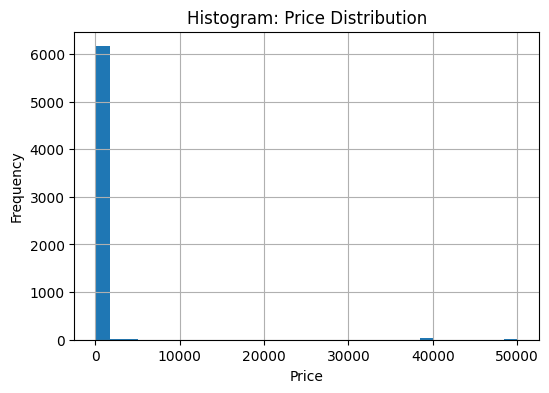

In [ ]:
plt.figure(figsize=(6,4))
df_slice_price1_20['price'].hist(bins=30)
plt.title('Histogram: Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# ommitting outliers over 30,000

df_slice_price1_20 = df_slice_price1_20[df_slice_price1_20['price'] <= 30000]

print("Maximum price after removing outliers:", df_slice_price1_20['price'].max())
print("Shape of DataFrame after removing outliers:", df_slice_price1_20.shape)

Maximum price after removing outliers: 9543.0
Shape of DataFrame after removing outliers: (6192, 21)


In [ ]:
df_slice_price1_20['host_response_rate'] = df['host_response_rate'].str.replace('%', '', regex=False).astype(float).fillna(0).astype(int)
df_slice_price1_20['host_acceptance_rate'] = df['host_acceptance_rate'].str.replace('%', '', regex=False).astype(float).fillna(0).astype(int)

print(f"Data type of 'host_response_rate' after conversion: {df_slice_price1_20['host_response_rate'].dtype}")
print(f"Data type of 'host_acceptance_rate' after conversion: {df_slice_price1_20['host_acceptance_rate'].dtype}")

print("First 5 values of 'host_response_rate' after conversion:")
print(df_slice_price1_20['host_response_rate'].head().to_string())
print("First 5 values of 'host_acceptance_rate' after conversion:")
print(df_slice_price1_20['host_acceptance_rate'].head().to_string())

Data type of 'host_response_rate' after conversion: int64
Data type of 'host_acceptance_rate' after conversion: int64
First 5 values of 'host_response_rate' after conversion:
0    100
1      0
2    100
4    100
5    100
First 5 values of 'host_acceptance_rate' after conversion:
0    100
1     70
2     99
4    100
5     98


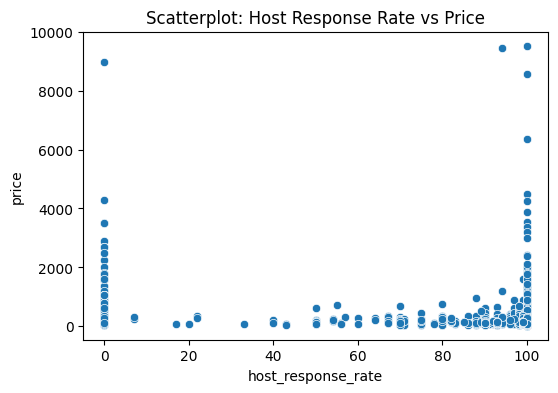

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_slice_price1_20, x='host_response_rate', y='price')
plt.title('Scatterplot: Host Response Rate vs Price')
plt.show()

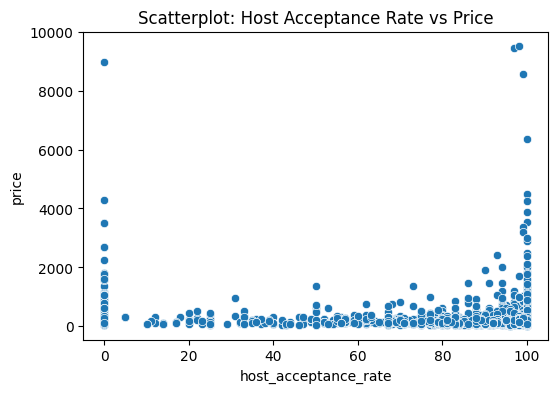

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_slice_price1_20, x='host_acceptance_rate', y='price')
plt.title('Scatterplot: Host Acceptance Rate vs Price')
plt.show()

In [ ]:
# to explore superhost, I converted f(alse) and t(rue) to 0 and 1
df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).fillna(0).astype(str)

print("First 5 values of 'host_is_superhost' after conversion:")
print(df['host_is_superhost'].head().to_string())
print(f"Data type of 'host_is_superhost' after conversion: {df['host_is_superhost'].dtype}")

First 5 values of 'host_is_superhost' after conversion:
0    0.0
1    0.0
2    1.0
3    1.0
4    0.0
Data type of 'host_is_superhost' after conversion: object


/tmp/ipython-input-2995862775.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).fillna(0).astype(str)


In [ ]:
continuous_cols = df_slice_price1_20.select_dtypes(include=['int64', 'float64']).columns

correlation_table = df_slice_price1_20[continuous_cols].corr()

print("Correlation Table of Continuous Variables:")
display(correlation_table.style.background_gradient(cmap='coolwarm', axis=None))

Correlation Table of Continuous Variables:


,id,price,scrape_id,host_id,host_response_rate,host_acceptance_rate
id,1.000000,0.040159,nan,0.507463,0.081216,0.083862
price,0.040159,1.000000,nan,0.011280,-0.024948,-0.025484
scrape_id,nan,nan,nan,nan,nan,nan
host_id,0.507463,0.011280,nan,1.000000,0.094667,0.102606
host_response_rate,0.081216,-0.024948,nan,0.094667,1.000000,0.690621
host_acceptance_rate,0.083862,-0.025484,nan,0.102606,0.690621,1.000000


Removed the outliers for price, to look at correlation again

Host response rate and host acceptance rate show no correlation.

#For columns 0-20 we kept "host_id" and "id" are kept as unique identifiers

No correlations were found between the first 20 columns vs price.  We changed data types and attempted different correlations, but nothing panned out for this set of columns.

#Columns 21-40

In [ ]:
df_slice21_40 = df.iloc[:, 21:40]

print(f"Original DataFrame shape: {df.shape}")
print(f"Selected DataFrame shape: {df.shape}")
print("First 5 rows of the selected columns:")
print(df_slice21_40.head())

Original DataFrame shape: (7444, 79)
Selected DataFrame shape: (7444, 79)
First 5 rows of the selected columns:
    host_neighbourhood  host_listings_count  host_total_listings_count  \
0            Riverbend                  1.0                        1.0   
1              Bywater                  1.0                        2.0   
2  St. Claude/St. Roch                  3.0                        3.0   
3         Seventh Ward                  1.0                        1.0   
4      Marigny/Bywater                  1.0                        1.0   

                 host_verifications host_has_profile_pic  \
0  ['email', 'phone', 'work_email']                    t   
1                ['email', 'phone']                    t   
2                ['email', 'phone']                    t   
3                ['email', 'phone']                    t   
4                ['email', 'phone']                    t   

  host_identity_verified            neighbourhood neighbourhood_cleansed  \
0     

In [ ]:
# checking missing data from rows 21-40
print("Missing values per column:")
print(df_slice21_40.isnull().sum())

Missing values per column:
host_neighbourhood               361
host_listings_count                2
host_total_listings_count          2
host_verifications                 2
host_has_profile_pic               2
host_identity_verified             2
neighbourhood                   3015
neighbourhood_cleansed             0
neighbourhood_group_cleansed    7444
latitude                           0
longitude                          0
property_type                      0
room_type                          0
accommodates                       0
bathrooms                       1190
bathrooms_text                    84
bedrooms                         147
beds                            1193
amenities                          0
dtype: int64


In [ ]:
# dropping neighborhood group cleansed as it has missing data
df_slice21_40 = df_slice21_40.drop(columns=['neighbourhood_group_cleansed'])

# drop the missing values from rows 21-40
df_slice21_40 = df_slice21_40.dropna()

In [ ]:
print("Missing values per column:")
print(df_slice21_40.isnull().sum())

Missing values per column:
host_neighbourhood           0
host_listings_count          0
host_total_listings_count    0
host_verifications           0
host_has_profile_pic         0
host_identity_verified       0
neighbourhood                0
neighbourhood_cleansed       0
latitude                     0
longitude                    0
property_type                0
room_type                    0
accommodates                 0
bathrooms                    0
bathrooms_text               0
bedrooms                     0
beds                         0
amenities                    0
dtype: int64


In [ ]:
# checking correlation within the variables in rows 21-40
correlation_21_40 = df_slice21_40.select_dtypes(include=['int64', 'float64']).columns
correlation_table_21_40 = df_slice21_40[correlation_21_40].corr()

# heatmap of correlation
print("Heatmap of Correlation of Rows 21-40:")
display(correlation_table_21_40.style.background_gradient(cmap='coolwarm', axis=None))

Heatmap of Correlation of Rows 21-40:


,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds
host_listings_count,1.000000,0.960129,-0.030442,0.052448,-0.069503,-0.065168,-0.099369,-0.079733
host_total_listings_count,0.960129,1.000000,-0.004219,0.070750,-0.053909,-0.055347,-0.079821,-0.071884
latitude,-0.030442,-0.004219,1.000000,0.496022,-0.016329,-0.030260,-0.011690,0.005165
longitude,0.052448,0.070750,0.496022,1.000000,0.073001,0.034951,0.040088,0.064910
accommodates,-0.069503,-0.053909,-0.016329,0.073001,1.000000,0.704986,0.832978,0.812123
bathrooms,-0.065168,-0.055347,-0.030260,0.034951,0.704986,1.000000,0.875508,0.819275
bedrooms,-0.099369,-0.079821,-0.011690,0.040088,0.832978,0.875508,1.000000,0.910584
beds,-0.079733,-0.071884,0.005165,0.064910,0.812123,0.819275,0.910584,1.000000


Based on the correlation map, there's multicollinearity between host_listings_count and host_total_listings_count, and another one for bed and bedrooms.

In [ ]:
# dropping host_listings_count as it heavy correlates with host_total_listings_count
df_slice21_40 = df_slice21_40.drop(columns=['host_listings_count'])

In [ ]:
# dropping beds as bedrooms would be a better representation for the dataset
df_slice21_40 = df_slice21_40.drop(columns=['beds'])

The variables host_listings_count and beds were removed due to high correlations with host_total_listings_count and bedrooms. Retaining both variables would ceate redundancy and multicollinearity.

In [ ]:
# checking for outliers from rows 21-40
numeric_cols_21_40 = df_slice21_40.select_dtypes(include=['int64', 'float64']).columns.tolist()

# calculating interquartile ranges
Q1 = df_slice21_40[numeric_cols_21_40].quantile(0.1)
Q3 = df_slice21_40[numeric_cols_21_40].quantile(0.9)
IQR = Q3 - Q1

# defining boundaries
lower_bound = Q1 - (3 * IQR)
upper_bound = Q3 + (3 * IQR)

# finding outliers
outliers_21_40 = ((df[numeric_cols_21_40] < lower_bound) | (df[numeric_cols_21_40] > upper_bound))

# display outliers
print("Outliers in Rows 21-40:")
print(outliers_21_40.sum())

# outliers in each row
outliers_per_row = outliers_21_40.sum(axis=1)
print("\nOutliers per Row:")
print(outliers_per_row.value_counts())

Outliers in Rows 21-40:
host_total_listings_count    270
latitude                      19
longitude                     30
accommodates                   0
bathrooms                     11
bedrooms                       7
dtype: int64

Outliers per Row:
0    7139
1     277
2      24
3       4
Name: count, dtype: int64


In [ ]:
print(df_slice21_40)

             host_neighbourhood  host_total_listings_count  \
0                     Riverbend                        1.0   
1                       Bywater                        2.0   
2           St. Claude/St. Roch                        3.0   
4               Marigny/Bywater                        1.0   
5               Marigny/Bywater                        3.0   
...                         ...                        ...   
7423  Central Business District                      342.0   
7430  Central Business District                        9.0   
7439  Central Business District                       36.0   
7442  Central Business District                       36.0   
7443  Central Business District                       36.0   

                    host_verifications host_has_profile_pic  \
0     ['email', 'phone', 'work_email']                    t   
1                   ['email', 'phone']                    t   
2                   ['email', 'phone']                    t   
4  

In [ ]:
# showing columns after removing certain rows from 21-40
print(f"Columns after removal")
print(df_slice21_40.columns)

Columns after removal
Index(['host_neighbourhood', 'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms',
       'amenities'],
      dtype='object')


In [ ]:
# transformation on host_total_listings_count using min-max scaling
pt = PowerTransformer(method='yeo-johnson', standardize=True)

# reshaping
col_data = df_slice21_40[['host_total_listings_count']].values.reshape(-1, 1)

# transforming
df_slice21_40['host_total_listings_transformed'] = pt.fit_transform(col_data)

# display the head of original and transformed
print("Original Distribution:")
print(df_slice21_40['host_total_listings_count'].head())

print("\nTransformed Distribution:")
print(df_slice21_40['host_total_listings_transformed'].head())

Original Distribution:
0    1.0
1    2.0
2    3.0
4    1.0
5    3.0
Name: host_total_listings_count, dtype: float64

Transformed Distribution:
0   -1.335847
1   -0.909952
2   -0.638956
4   -1.335847
5   -0.638956
Name: host_total_listings_transformed, dtype: float64


Histogram of Original and Transformed Data:


array([[<Axes: title={'center': 'host_total_listings_count'}>,
        <Axes: title={'center': 'host_total_listings_transformed'}>]],
      dtype=object)

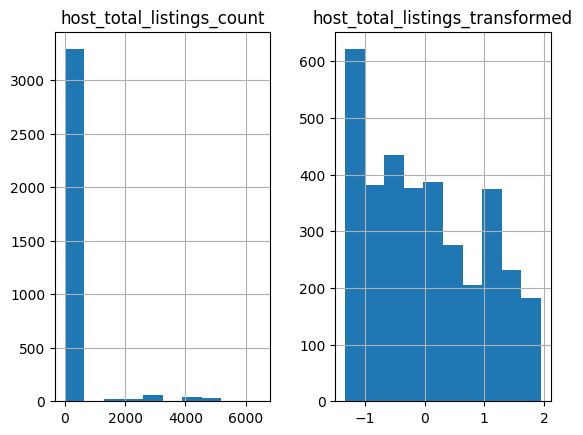

In [ ]:
# histogram of both original and transformed
print("Histogram of Original and Transformed Data:")
df_slice21_40[['host_total_listings_count', 'host_total_listings_transformed']].hist()

The Yeo-Johnson method transformation was kept for host_total_listings_count because the original data was highly skewed with very large values. The transformation made the distribution more balanced and less influenced with exteme values.

#Columns 41-60

In [ ]:
selected_columns = df.columns[40:60]
df_slice41_60 = df[selected_columns]

print(f"Original DataFrame shape: {df.shape}")
print(f"Selected DataFrame shape: {df.shape}")
print("First 5 rows of the selected columns:")
print(df_slice41_60.head())

Original DataFrame shape: (7444, 79)
Selected DataFrame shape: (7444, 79)
First 5 rows of the selected columns:
     price  minimum_nights  maximum_nights  minimum_minimum_nights  \
0   $61.00               1             365                     1.0   
1  $150.00              30            1125                    30.0   
2   $85.00               3            1125                     3.0   
3      NaN               3              29                     3.0   
4   $84.00              30              91                    30.0   

   maximum_minimum_nights  minimum_maximum_nights  maximum_maximum_nights  \
0                     1.0                   365.0                   365.0   
1                    30.0                  1125.0                  1125.0   
2                     3.0                  1125.0                  1125.0   
3                     3.0                    29.0                    29.0   
4                    30.0                    91.0                    91.0   

   m

In [ ]:
# Convert 'price' column to numeric, handling non-numeric characters and missing values
df_slice41_60['price'] = df_slice41_60['price'].astype(str).str.replace(r'[$,]', '', regex=True)
df_slice41_60['price'] = pd.to_numeric(df_slice41_60['price'], errors='coerce')

print("First 5 rows of df after reverting price imputation:")
print(df_slice41_60.head())
print("\nMissing values after reverting price imputation:")
print(df_slice41_60.isnull().sum())

First 5 rows of df after reverting price imputation:
   price  minimum_nights  maximum_nights  minimum_minimum_nights  \
0   61.0               1             365                     1.0   
1  150.0              30            1125                    30.0   
2   85.0               3            1125                     3.0   
3    NaN               3              29                     3.0   
4   84.0              30              91                    30.0   

   maximum_minimum_nights  minimum_maximum_nights  maximum_maximum_nights  \
0                     1.0                   365.0                   365.0   
1                    30.0                  1125.0                  1125.0   
2                     3.0                  1125.0                  1125.0   
3                     3.0                    29.0                    29.0   
4                    30.0                    91.0                    91.0   

   minimum_nights_avg_ntm  maximum_nights_avg_ntm  calendar_updated  \
0   

/tmp/ipython-input-2101255417.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice41_60['price'] = df_slice41_60['price'].astype(str).str.replace(r'[$,]', '', regex=True)
/tmp/ipython-input-2101255417.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice41_60['price'] = pd.to_numeric(df_slice41_60['price'], errors='coerce')


In [ ]:
# Check for missing values in each column
print("Missing values per column:")
print(df_slice41_60.isnull().sum())

# Check the total number of missing values in the DataFrame
print("\nTotal missing values in the dataset:")
print(df_slice41_60.isnull().sum().sum())

Missing values per column:
price                     1211
minimum_nights               0
maximum_nights               0
minimum_minimum_nights       2
maximum_minimum_nights       2
minimum_maximum_nights       2
maximum_maximum_nights       2
minimum_nights_avg_ntm       0
maximum_nights_avg_ntm       0
calendar_updated          7444
has_availability           249
availability_30              0
availability_60              0
availability_90              0
availability_365             0
calendar_last_scraped        0
number_of_reviews            0
number_of_reviews_ltm        0
number_of_reviews_l30d       0
availability_eoy             0
dtype: int64

Total missing values in the dataset:
8912


In [ ]:
# Drop the 'calendar_updated' column due to all missing values
df_slice41_60 = df_slice41_60.drop(columns=['calendar_updated'])

print("Columns after dropping 'calendar_updated':")
print(df_slice41_60.columns)
print("\nMissing values after dropping 'calendar_updated':")
print(df_slice41_60.isnull().sum())

Columns after dropping 'calendar_updated':
Index(['price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'calendar_last_scraped', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'availability_eoy'],
      dtype='object')

Missing values after dropping 'calendar_updated':
price                     1211
minimum_nights               0
maximum_nights               0
minimum_minimum_nights       2
maximum_minimum_nights       2
minimum_maximum_nights       2
maximum_maximum_nights       2
minimum_nights_avg_ntm       0
maximum_nights_avg_ntm       0
has_availability           249
availability_30              0
availability_60              0
availability_90              0
availability_365

In [ ]:
## as we know, when we have missing data in our target varible (price) we have to drop those rows.
## We can't train a model on an unknown target.
missing_price_indices = df_slice41_60[df_slice41_60['price'].isnull()].index

# Drop the rows with missing 'price' values
df_slice41_60.drop(missing_price_indices, inplace=True)

# Verify that the rows have been dropped by checking for missing 'price' values again
print("\nMissing values after dropping rows with missing price:")
print(df_slice41_60.isnull().sum())

# Verify the new shape of the DataFrame
print("\nShape of DataFrame after dropping rows with missing price:")
df_slice41_60.shape


Missing values after dropping rows with missing price:
price                      0
minimum_nights             0
maximum_nights             0
minimum_minimum_nights     2
maximum_minimum_nights     2
minimum_maximum_nights     2
maximum_maximum_nights     2
minimum_nights_avg_ntm     0
maximum_nights_avg_ntm     0
has_availability          38
availability_30            0
availability_60            0
availability_90            0
availability_365           0
calendar_last_scraped      0
number_of_reviews          0
number_of_reviews_ltm      0
number_of_reviews_l30d     0
availability_eoy           0
dtype: int64

Shape of DataFrame after dropping rows with missing price:


(6233, 19)

In [ ]:
## now we are checking the variability of 'has_availability' to see if it would be useful to keep
df_slice41_60['has_availability'].value_counts(dropna=False)

,count
has_availability,
t,6195
NaN,38


In [ ]:
## Nearly all listings were marked as available,
# and the remaining missing values were minimal.
# Because variables with little to no variance do not contribute predictive value,
# I decided to remove this column.

df_slice41_60 = df_slice41_60.drop(columns=['has_availability'])

print("Columns after dropping 'has_availability':")
print(df_slice41_60.columns)
print("\nMissing values after dropping 'has_availability':")
print(df_slice41_60.isnull().sum())

Columns after dropping 'has_availability':
Index(['price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'availability_30', 'availability_60',
       'availability_90', 'availability_365', 'calendar_last_scraped',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy'],
      dtype='object')

Missing values after dropping 'has_availability':
price                     0
minimum_nights            0
maximum_nights            0
minimum_minimum_nights    2
maximum_minimum_nights    2
minimum_maximum_nights    2
maximum_maximum_nights    2
minimum_nights_avg_ntm    0
maximum_nights_avg_ntm    0
availability_30           0
availability_60           0
availability_90           0
availability_365          0
calendar_last_scraped     0
number_of_reviews         0
number_of_reviews_l

In [ ]:
## now lets check for missing values again to see if everything looks good

print("Missing values per column:")
print(df_slice41_60.isnull().sum())

# Check the total number of missing values in the DataFrame
print("\nTotal missing values in the dataset:")
print(df_slice41_60.isnull().sum().sum())

## we are seeing an interesting output, but we like it.
## now the question becomes, for price predicitions, do we need different versions
## of the same booking information? probably not. so let's drop these four.

Missing values per column:
price                     0
minimum_nights            0
maximum_nights            0
minimum_minimum_nights    2
maximum_minimum_nights    2
minimum_maximum_nights    2
maximum_maximum_nights    2
minimum_nights_avg_ntm    0
maximum_nights_avg_ntm    0
availability_30           0
availability_60           0
availability_90           0
availability_365          0
calendar_last_scraped     0
number_of_reviews         0
number_of_reviews_ltm     0
number_of_reviews_l30d    0
availability_eoy          0
dtype: int64

Total missing values in the dataset:
8


In [ ]:
## dropping all four of the minimum, maximum different versions
## Several nightly restriction variables were represented variations of the same booking constraint.
# To reduce redundancy,
# only the primary minimum and maximum night variables were retained.

df_slice41_60 = df_slice41_60.drop(columns=[
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights'
])

# Check for listings with no reviews
listings_no_reviews = df_slice41_60[df_slice41_60['number_of_reviews'] == 0]

print("Listings with no reviews:")
print(listings_no_reviews.head()) # Displaying the first 5 rows of such listings
print(f"Total number of listings with no reviews: {len(listings_no_reviews)}")

Listings with no reviews:
     price  minimum_nights  maximum_nights  minimum_nights_avg_ntm  \
28   245.0              30              60                    30.0   
248  318.0              30            1125                    30.0   
426   40.0              30             730                    30.0   
458  200.0              30            1125                    30.0   
498  104.0              30            1125                    30.0   

     maximum_nights_avg_ntm  availability_30  availability_60  \
28                     60.0               30               60   
248                  1125.0               30               60   
426                   730.0                0                0   
458                  1125.0               30               60   
498                  1125.0               27               57   

     availability_90  availability_365 calendar_last_scraped  \
28                90                90            2025-09-11   
248               90              

In [ ]:
## now let's recheck for missing values

print("Missing values per column:")
print(df_slice41_60.isnull().sum())

# Check the total number of missing values in the DataFrame
print("\nTotal missing values in the dataset:")
print(df_slice41_60.isnull().sum().sum())

## all clean

Missing values per column:
price                     0
minimum_nights            0
maximum_nights            0
minimum_nights_avg_ntm    0
maximum_nights_avg_ntm    0
availability_30           0
availability_60           0
availability_90           0
availability_365          0
calendar_last_scraped     0
number_of_reviews         0
number_of_reviews_ltm     0
number_of_reviews_l30d    0
availability_eoy          0
dtype: int64

Total missing values in the dataset:
0


In [ ]:
#dropping calend

In [ ]:
df_slice41_60[['availability_30','availability_60','availability_90', 'availability_365']].corr()

## there is high correlation between 30,60,90
# availability_30 vs availability_60 → 0.92
# availability_60 vs availability_90 → 0.96
# availability_30 vs availability_90 → 0.86
# whereas, 365 has low correlations with the rest
# this means that we can keep one of the short-term availabilities AND the long-term one

,availability_30,availability_60,availability_90,availability_365
availability_30,1.000000,0.915743,0.855507,0.259825
availability_60,0.915743,1.000000,0.963227,0.344714
availability_90,0.855507,0.963227,1.000000,0.406509
availability_365,0.259825,0.344714,0.406509,1.000000


In [ ]:
# keeping 'availability_90' and 'availability_365' One captures short-term booking dynamics
# and the other captures long-term availability strategy.

#lets drop the rest
df_slice41_60 = df_slice41_60.drop(columns=['availability_30', 'availability_60', 'availability_365'])
print(df_slice41_60.head())

   price  minimum_nights  maximum_nights  minimum_nights_avg_ntm  \
0   61.0               1             365                     1.0   
1  150.0              30            1125                    30.0   
2   85.0               3            1125                     3.0   
4   84.0              30              91                    30.0   
5   80.0               1              30                     1.0   

   maximum_nights_avg_ntm  availability_90 calendar_last_scraped  \
0                   365.0               61            2025-09-11   
1                  1125.0               81            2025-09-11   
2                  1125.0               13            2025-09-11   
4                    91.0               46            2025-09-11   
5                  1125.0               40            2025-09-11   

   number_of_reviews  number_of_reviews_ltm  number_of_reviews_l30d  \
0                510                      7                       3   
1                316                    

In [ ]:
# now let's find the correlation between 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d'
df_slice41_60[['number_of_reviews','number_of_reviews_ltm','number_of_reviews_l30d']].corr()

,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d
number_of_reviews,1.000000,0.632090,0.321529
number_of_reviews_ltm,0.632090,1.000000,0.662632
number_of_reviews_l30d,0.321529,0.662632,1.000000


In [ ]:
## these correlations aren't too high and I can't decide what to do.
# let's see how the reviews correlate with the price

df_slice41_60[['price','number_of_reviews','number_of_reviews_ltm','number_of_reviews_l30d']].corr()


,price,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d
price,1.000000,-0.057853,-0.059014,-0.030962
number_of_reviews,-0.057853,1.000000,0.632090,0.321529
number_of_reviews_ltm,-0.059014,0.632090,1.000000,0.662632
number_of_reviews_l30d,-0.030962,0.321529,0.662632,1.000000


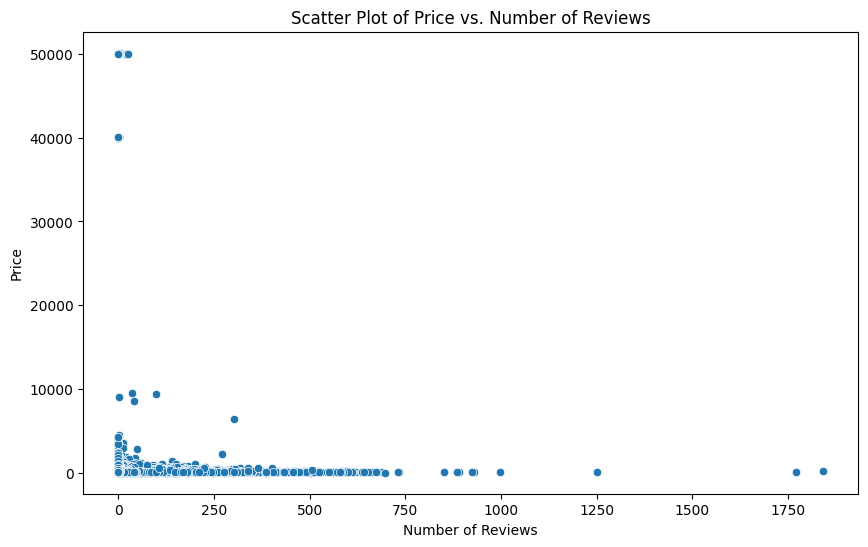

The correlation between number_of_reviews and price is: -0.0579


In [ ]:
# i still can't decide. let's create a scatterplot of price and reviews to see where the points lie

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_slice41_60, x='number_of_reviews', y='price')
plt.title('Scatter Plot of Price vs. Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.show()

# Print the correlation
correlation = df_slice41_60['number_of_reviews'].corr(df_slice41_60['price'])
print(f"The correlation between number_of_reviews and price is: {correlation:.4f}")


## there are some outliers, but this roughly shows that there are more reviews as the price drops

In [ ]:
## if we keep all three, our dataset would be redundant.
## we can keep l30d since it could be affected by a seasonal change and can help us predict price
## depending on the season
## ltm should be dropped and instead, we keep the total number of reviews or 'number_of_reviews'
## we are keeping short-term demand spikes and overall long-term brand reputation

# dropping 'number_of_reviews_ltm'
df_slice41_60 = df_slice41_60.drop(columns=['number_of_reviews_ltm'])
print(df_slice41_60.head())

   price  minimum_nights  maximum_nights  minimum_nights_avg_ntm  \
0   61.0               1             365                     1.0   
1  150.0              30            1125                    30.0   
2   85.0               3            1125                     3.0   
4   84.0              30              91                    30.0   
5   80.0               1              30                     1.0   

   maximum_nights_avg_ntm  availability_90 calendar_last_scraped  \
0                   365.0               61            2025-09-11   
1                  1125.0               81            2025-09-11   
2                  1125.0               13            2025-09-11   
4                    91.0               46            2025-09-11   
5                  1125.0               40            2025-09-11   

   number_of_reviews  number_of_reviews_l30d  availability_eoy  
0                510                       3                83  
1                316                       0        

In [ ]:
#now lets check for outliers in 'price'
df_slice41_60['price'].describe()


## this shows us that most of the airbnb's are priced between $89 and $221
## and the max of ~$50,000 is an outlier

,price
count,6233.000000
mean,488.049414
std,3533.460991
min,15.000000
25%,89.000000
50%,132.000000
75%,221.000000
max,50134.000000


In [ ]:
# calculate interquartile range (IQR)
q1 = df_slice41_60['price'].quantile(0.1)
q3 = df_slice41_60['price'].quantile(0.9)
iqr = q3 - q1

# define the boundaries for an outlier
lower_bound = q1 - (3 * iqr)
upper_bound = q3 + (3 * iqr)

# find the outliers
outliers = df_slice41_60[(df_slice41_60['price'] < lower_bound) | (df_slice41_60['price'] > upper_bound)]

# display the outliers
print(outliers)


        price  minimum_nights  maximum_nights  minimum_nights_avg_ntm  \
76     9461.0              30             730                    30.0   
124    1369.0               3              30                     2.9   
139    2262.0             120            1125                   120.0   
850    6375.0              30            1123                    30.0   
1092   1893.0               3               7                     3.0   
...       ...             ...             ...                     ...   
7418  50000.0               1             365                     1.0   
7420  50000.0               1             365                     1.0   
7423  50000.0               1             365                     1.0   
7424  50000.0               1             365                     1.0   
7425  50000.0               1             365                     1.0   

      maximum_nights_avg_ntm  availability_90 calendar_last_scraped  \
76                     730.0                0       

In [ ]:
high_price_outliers = df_slice41_60[df_slice41_60['price'] >= 30000]

print("Number of listings equal to or above 30,000:")
print(len(high_price_outliers))

print("\nListings equal to or above 30,000:")
print(high_price_outliers[['price']])


## as most of these don't have a random extra 0 at the end, we can't assume that they are typos.
## standardizing would be useful if the values were in different scales
## (at first we thought that those values must be annual price, but that wasn't the case
##  since the number of minimum days wasn't 365)
## transforming would essentially change the scale AND the distribution of the data
## (we thought that maybe they were luxury listings, but as we checked in the airbnb app,
## the highest $ amount was ~9000)
## instead, I think it is best to just exlude them from our analysis

Number of listings equal to or above 30,000:
41

Listings equal to or above 30,000:
        price
4394  50034.0
4611  40000.0
4614  40000.0
4615  40000.0
4655  50000.0
4704  50034.0
4705  40034.0
4706  40034.0
4707  40034.0
4708  40034.0
4709  40034.0
4710  40034.0
4711  50034.0
4713  40034.0
4714  50034.0
4716  40034.0
4717  40034.0
4718  40034.0
4719  50034.0
4720  40034.0
4722  50067.0
4724  50134.0
4791  40000.0
4792  40000.0
4793  40000.0
4794  40000.0
4796  40000.0
5236  40034.0
5237  40034.0
5239  40034.0
5251  40034.0
5252  50034.0
5253  40034.0
7033  40034.0
7122  40067.0
7365  40034.0
7418  50000.0
7420  50000.0
7423  50000.0
7424  50000.0
7425  50000.0


In [ ]:
## what we used to check if minimum nights was 365

df_slice41_60[df_slice41_60['price'] >= 30000][['price','minimum_nights','maximum_nights']]

,price,minimum_nights,maximum_nights
4394,50034.0,1,1125
4611,40000.0,1,1125
4614,40000.0,1,1125
4615,40000.0,1,1125
4655,50000.0,1,1125
4704,50034.0,1,1125
4705,40034.0,1,1125
4706,40034.0,1,1125
4707,40034.0,1,1125
4708,40034.0,1,1125


In [ ]:
# ommitting outliers over 30,000

df_slice41_60 = df_slice41_60[df_slice41_60['price'] <= 30000]

print("Maximum price after removing outliers:", df_slice41_60['price'].max())
print("Shape of DataFrame after removing outliers:", df_slice41_60.shape)

Maximum price after removing outliers: 9543.0
Shape of DataFrame after removing outliers: (6192, 10)


In [ ]:
# checking the distribution again
df_slice41_60['price'].describe()

## amazing!! our max matches the highest price in the airbnb app


,price
count,6192.000000
mean,203.638243
std,346.121926
min,15.000000
25%,88.000000
50%,132.000000
75%,218.000000
max,9543.000000


In [ ]:
## checking for outliers in the rest of our numeric variables

numeric_cols = df_slice41_60.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    Q1 = df_slice41_60[col].quantile(0.25)
    Q3 = df_slice41_60[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_slice41_60[(df_slice41_60[col] < lower) | (df_slice41_60[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

    ## i am okay with these outliers
    ## for example, a listing having 500 reviews might show up as an outlier
    ## but it isn't an anomaly, it is just popularity


price: 475 outliers
minimum_nights: 30 outliers
maximum_nights: 1085 outliers
minimum_nights_avg_ntm: 30 outliers
maximum_nights_avg_ntm: 8 outliers
availability_90: 0 outliers
number_of_reviews: 424 outliers
number_of_reviews_l30d: 467 outliers
availability_eoy: 217 outliers


In [ ]:
## dropping 'calendar_scraped' since it only tells us information about the dataset and not price
df_slice41_60 = df_slice41_60.drop(columns=['calendar_last_scraped'])
print(df_slice41_60.head())

In [ ]:
## dropping 'minimum_nights_avg_ntm' and 'maximum_nights_avg_ntm' since they don't provide useful information about the price


In [ ]:
## dropping 'availability_eoy' since

# Columns 61-79

In [ ]:
selected_columns = df.columns[61:80]
df_slice61_80 = df[selected_columns]

In [ ]:
df.iloc[:, 61:80].head()

,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,70,4270.0,2010-04-16,2025-08-31,4.89,4.95,4.87,4.97,4.98,4.68,4.91,"25-NSTR-11772, 25-OSTR-11151",f,1,1,0,0,2.72
1,255,38250.0,2011-02-16,2025-05-07,4.94,4.92,4.93,4.98,4.98,4.84,4.89,"21-RSTR-18609, 22-OSTR-20720",f,1,1,0,0,1.78
2,255,21675.0,2011-03-15,2025-06-29,4.90,4.93,4.96,4.94,4.96,4.67,4.85,23-XSTR-13082,f,3,3,0,0,3.75
3,255,NaN,2011-05-03,2025-09-04,4.90,4.94,4.95,4.98,4.98,4.56,4.87,"23-NSTR-15067, 24-OSTR-20882",t,1,1,0,0,4.57
4,180,15120.0,2011-03-16,2025-03-05,4.96,4.95,4.99,4.99,4.99,4.84,4.94,"23-ISTR-02823, 23-OSTR-02823",f,1,1,0,0,2.86


In [ ]:
# --- STEP 1: PREVENT TARGET LEAKAGE ---
# Dropping 'estimated_revenue' because it is derived from Price * Occupancy.
# Including it would be cheating (Data Leakage).
df = df.drop(columns=['estimated_revenue_l365d'])

# --- STEP 2: DATE TRANSFORMATION ---
# Convert string dates to datetime objects
df['first_review'] = pd.to_datetime(df['first_review'])
df['last_review'] = pd.to_datetime(df['last_review'])

In [ ]:
# Set a reference date (today) to calculate "Days Since"#
ref_date = pd.to_datetime('today')

In [ ]:
# Calculate the difference in days. Fill NaNs with 0 (assuming 0 days of history if no reviews)
df['days_since_first_review'] = (ref_date - df['first_review']).dt.days.fillna(0)
df['days_since_last_review'] = (ref_date - df['last_review']).dt.days.fillna(0)

In [ ]:
# Drop the original date columns as they are no longer needed
df = df.drop(columns=['first_review', 'last_review'])

In [ ]:
# --- STEP 3: TEXT & BOOLEAN TRANSFORMATION ---
# Convert 't'/'f' to 1/0
df['instant_bookable'] = df['instant_bookable'].map({'t': 1, 'f': 0})

In [ ]:
# Convert specific license text to a simple "Has License" (1) or "No License" (0)
df['has_license'] = df['license'].notnull().astype(int)
df = df.drop(columns=['license'])

In [ ]:
# Check the new columns
print(df[['days_since_first_review', 'days_since_last_review', 'instant_bookable', 'has_license']].head())

   days_since_first_review  days_since_last_review  instant_bookable  \
0                   5785.0                   169.0                 0   
1                   5479.0                   285.0                 0   
2                   5452.0                   232.0                 0   
3                   5403.0                   165.0                 1   
4                   5451.0                   348.0                 0   

   has_license  
0            1  
1            1  
2            1  
3            1  
4            1  





*   **estimated_revenue_l365d**
This column was dropped from the dataset. Since the project goal is to predict "price," including estimated revenue would cause Data Leakage. Revenue is a direct calculation of Price × Occupancy; including it would allow the model to reverse-engineer the target variable rather than predicting it based on property attributes.
*   **first_review & last_review**
These columns contained raw date strings (e.g., "2019-01-01"), which regression models cannot process. We transformed these into numerical features: days_since_first_review and days_since_last_review. This creates a continuous variable representing the "age" of the listing's history and the "recency" of its activity. Missing values were imputed with 0.
*  **instant_bookable**
The original column was a categorical object using "t" and "f" strings. I recoded this into a binary integer format (1 for True, 0 for False) so it could be interpreted by the model.
*   **license**
This column contained high-cardinality text strings (specific permit numbers) which are unique to listings and offer no generalizable predictive power. However, the presence of a license is significant. I converted this into a binary has_license feature (1 if a license exists, 0 if null) and dropped the original text column.




In [ ]:
# --- STEP 4: HANDLING MISSING REVIEW SCORES ---
# Define the list of review score columns
score_cols = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]

# Impute missing values with the median.
# We use median because ratings are left-skewed (mostly 4.5-5.0),
# so the mean would be misleading if there are low outliers.
for col in score_cols:
    df[col] = df[col].fillna(df[col].median())

# Handle 'reviews_per_month'
# If this is missing, it means there are 0 reviews, so the rate is 0/month.
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)


# --- STEP 5: REMOVING MULTICOLLINEARITY ---
# 'calculated_host_listings_count' is the sum of entire_homes + private_rooms + shared_rooms.
# We keep the total count and drop the sub-categories to avoid redundancy (Multicollinearity).
cols_to_drop = [
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms'
]
df = df.drop(columns=cols_to_drop)

# Verify the changes
print(df[score_cols].info())
print(f"Remaining Columns: {df.columns.tolist()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7444 entries, 0 to 7443
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   review_scores_rating         7444 non-null   float64
 1   review_scores_accuracy       7444 non-null   float64
 2   review_scores_cleanliness    7444 non-null   float64
 3   review_scores_checkin        7444 non-null   float64
 4   review_scores_communication  7444 non-null   float64
 5   review_scores_location       7444 non-null   float64
 6   review_scores_value          7444 non-null   float64
dtypes: float64(7)
memory usage: 407.2 KB
None
Remaining Columns: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbn

*   **review_scores_rating** (and all sub-scores)
These columns had approximately 1,290 missing values (approx. 17% of the data). Dropping these rows would result in significant data loss. Upon inspection, the distribution of review scores is heavily left-skewed, with the vast majority of ratings falling between 4.5 and 5.0. To preserve the data structure, we imputed these missing values using the median of each respective column. The median was chosen over the mean to avoid distortion from rare, extremely low ratings (1-star outliers).
*   **reviews_per_month**
Missing values in this column correspond to listings that have zero reviews. Therefore, a missing value logically equates to a rate of 0 reviews per month. We imputed these NaN values with 0.0.

*   **calculated_host_listings_count_**... (entire_homes, private_rooms, shared_rooms)
These three columns were dropped to prevent Multicollinearity. The dataset already contains calculated_host_listings_count, which is the aggregate sum of these three sub-categories. Including both the total and the constituent parts would provide the model with perfectly redundant information, which can destabilize regression coefficients. I retained only the total count variable.

Applied Yeo-Johnson Transform to: calculated_host_listings_count
Applied Yeo-Johnson Transform to: reviews_per_month
Applied Yeo-Johnson Transform to: number_of_reviews_ly
Applied Yeo-Johnson Transform to: estimated_occupancy_l365d


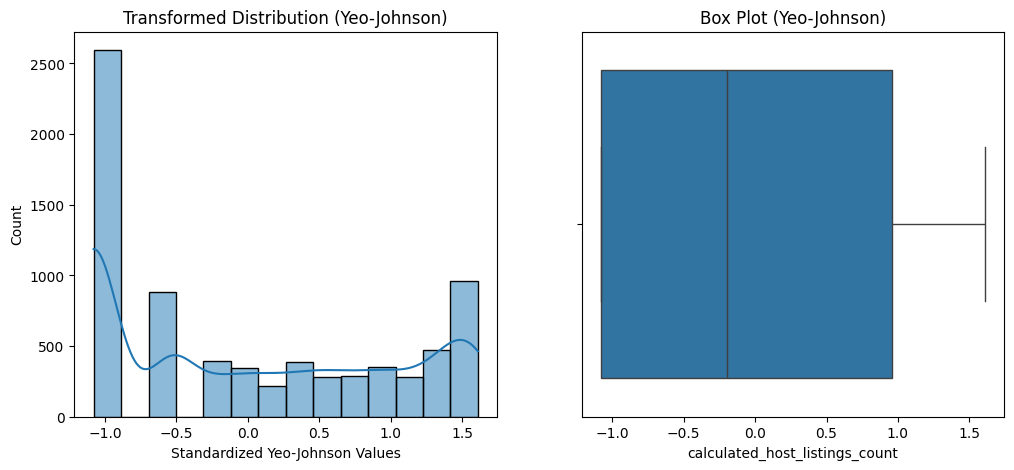

In [ ]:
from sklearn.preprocessing import PowerTransformer

# --- STEP 6: ADVANCED TRANSFORMATION ---
# We use PowerTransformer with method='yeo-johnson'.
# It automatically finds the best parameter to make the data Normal.
# standardize=True also scales the data (Z-score)

cols_to_transform = [
    'calculated_host_listings_count',
    'reviews_per_month',
    'number_of_reviews_ly',
    'estimated_occupancy_l365d'
]

# Initialize the transformer
pt = PowerTransformer(method='yeo-johnson', standardize=True)

# Loop through and transform each column
for col in cols_to_transform:
    # Reshape data to 2D array as required by sklearn
    col_data = df[[col]]

    # Fit and transform
    df[col] = pt.fit_transform(col_data)

    print(f"Applied Yeo-Johnson Transform to: {col}")

# --- VISUALIZATION CHECK ---
# Visualize the first column to see the result
plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
sns.histplot(df['calculated_host_listings_count'], kde=True)
plt.title('Transformed Distribution (Yeo-Johnson)')
plt.xlabel('Standardized Yeo-Johnson Values')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['calculated_host_listings_count'])
plt.title('Box Plot (Yeo-Johnson)')
plt.show()

# --- STEP 7: FINAL EXPORT ---
df.to_csv('cleaned_airbnb_dataset.csv', index=False)

For the skewed variables calculated_host_listings_count, reviews_per_month, number_of_reviews_ly, and estimated_occupancy_l365d, we utilized the Yeo-Johnson Power Transformation.
Why:The Yeo-Johnson method automates the selection of the optimal power parameter to minimize skewness and maximize normality. Yeo-Johnson handles zero and negative values natively, which was essential for columns like reviews_per_month that contain zeros.
Standardization: we also enabled standardize=True, which centers the transformed data (mean = 0, variance = 1). This ensures that these high-variance features do not disproportionately influence the model weights due to scale differences.

We chose not to drop outliers because they represent valid, high-value data points (e.g., professional property managers). Removing them would have introduced Selection Bias, causing the model to underperform on high-revenue listings. Instead, we used the Yeo-Johnson transformation to normalize their impact while preserving their predictive signal.

--- 1. MISSING VALUES CHECK ---
number_of_reviews_ly              0
estimated_occupancy_l365d         0
review_scores_rating              0
review_scores_accuracy            0
review_scores_cleanliness         0
review_scores_checkin             0
review_scores_communication       0
review_scores_location            0
review_scores_value               0
instant_bookable                  0
calculated_host_listings_count    0
reviews_per_month                 0
days_since_first_review           0
days_since_last_review            0
has_license                       0
dtype: int64

--- 2. DATA TYPE CHECK ---
number_of_reviews_ly              float64
estimated_occupancy_l365d         float64
review_scores_rating              float64
review_scores_accuracy            float64
review_scores_cleanliness         float64
review_scores_checkin             float64
review_scores_communication       float64
review_scores_location            float64
review_scores_value               float64
instant_b

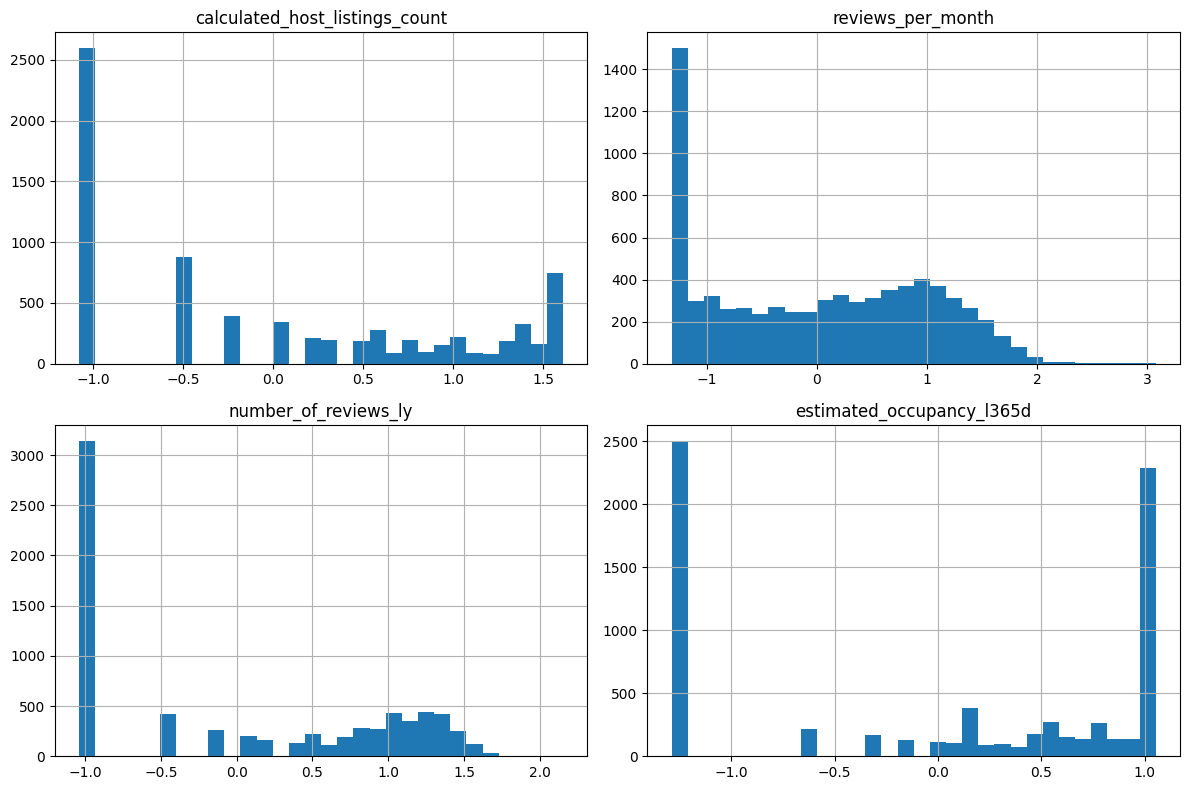

In [ ]:
# --- FINAL VERIFICATION BLOCK ---

# 1. Define the columns we expect to have in the final dataset
final_cols = [
    'number_of_reviews_ly',
    'estimated_occupancy_l365d',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'instant_bookable',            # Should be 0 or 1
    'calculated_host_listings_count',
    'reviews_per_month',
    'days_since_first_review',     # Should be numeric
    'days_since_last_review',      # Should be numeric
    'has_license'                  # Should be 0 or 1
]

print("--- 1. MISSING VALUES CHECK ---")
print(df[final_cols].isnull().sum())

print("\n--- 2. DATA TYPE CHECK ---")
print(df[final_cols].dtypes)

print("\n--- 3. TRANSFORMATION CHECK (Skewness) ---")
# If Yeo-Johnson worked, these values should be close to 0 (between -0.5 and 0.5 is ideal)
transformed_vars = [
    'calculated_host_listings_count',
    'reviews_per_month',
    'number_of_reviews_ly',
    'estimated_occupancy_l365d'
]
print(df[transformed_vars].skew())

print("\n--- 4. VISUAL PROOF (Histograms) ---")
# Plotting the transformed columns to confirm they look 'Normal-ish'
df[transformed_vars].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

#Create .csv file with columns to keep.

***List of columns kept***

id

host_id

(columns 21-40)

neighbourhood_cleansed

latitude

longitude

property_type

room_type

accomodates

bathrooms

bedrooms

host_total_listings_count


(columns 41:60)

price

minimum_nights

maximum_nights

availability_90

availability_365

number_of_reviews  

number_of_reviews_l30d

(column 61-80)

calculated_host_listings_count  

reviews_per_month       

number_of_reviews_ly  

estimated_occupancy_l365d



#Cleaned data frame based on review of columns grouped 20.

***Columns kept***

In [ ]:
columns_to_keep = [
    'id',
    'host_id',
    'neighbourhood_cleansed',
    'latitude',
    'longitude',
    'property_type',
    'room_type',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'host_total_listings_count',
    'price',
    'minimum_nights',
    'maximum_nights',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm',
    'availability_90',
    'availability_365',
    'calendar_last_scraped',
    'number_of_reviews',
    'number_of_reviews_l30d',
    'availability_eoy',
    'number_of_reviews_ly',
    'estimated_occupancy_l365d',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'instant_bookable',
    'calculated_host_listings_count',
    'reviews_per_month',
    'days_since_first_review',
    'days_since_last_review',
    'has_license'
]

# Create the new DataFrame with selected columns
listings_cleansed_df = df[columns_to_keep].copy()

# Save the new DataFrame to a CSV file
listings_cleansed_df.to_csv('listings_cleansed.csv', index=False)

print("DataFrame 'listings_cleansed.csv' created successfully with the specified columns.")
print(f"Shape of the new DataFrame: {listings_cleansed_df.shape}")
print("First 5 rows of the new DataFrame:")
display(listings_cleansed_df.head())

DataFrame 'listings_cleansed.csv' created successfully with the specified columns.
Shape of the new DataFrame: (7444, 37)
First 5 rows of the new DataFrame:


,id,host_id,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,host_total_listings_count,price,minimum_nights,maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,reviews_per_month,days_since_first_review,days_since_last_review,has_license
0,19091,72880,Leonidas,29.96100,-90.11950,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,$61.00,1,365,1.0,365.0,61,331,2025-09-11,510,3,83,-1.038942,0.247964,4.89,4.95,4.87,4.97,4.98,4.68,4.91,0,-1.080002,1.180588,5785.0,169.0,1
1,71624,367223,Bywater,29.96153,-90.04364,Entire rental unit,Entire home/apt,2,1.0,1.0,2.0,$150.00,30,1125,30.0,1125.0,81,356,2025-09-11,316,0,103,1.041495,1.052461,4.94,4.92,4.93,4.98,4.98,4.84,4.89,0,-1.080002,0.759060,5479.0,285.0,1
2,74498,391462,St. Roch,29.96986,-90.05172,Entire rental unit,Entire home/apt,3,1.0,1.0,3.0,$85.00,3,1125,3.0,1125.0,13,231,2025-09-11,662,0,27,1.376633,1.052461,4.90,4.93,4.96,4.94,4.96,4.67,4.85,0,-0.198694,1.489679,5452.0,232.0,1
3,79536,428362,Seventh Ward,29.97803,-90.07450,Entire rental unit,Entire home/apt,2,NaN,1.0,1.0,NaN,3,29,3.0,29.0,0,0,2025-09-11,799,7,0,1.500126,1.052461,4.90,4.94,4.95,4.98,4.98,4.56,4.87,1,-1.080002,1.671572,5403.0,165.0,1
4,79609,428909,St. Claude,29.96448,-90.03667,Entire guest suite,Entire home/apt,3,1.0,2.0,1.0,$84.00,30,91,30.0,91.0,46,291,2025-09-11,505,0,59,0.988004,0.813101,4.96,4.95,4.99,4.99,4.99,4.84,4.94,0,-1.080002,1.229776,5451.0,348.0,1


In [ ]:
#show missing values
listings_cleansed_df.isnull().sum()

,0
id,0
host_id,0
neighbourhood_cleansed,0
latitude,0
longitude,0
property_type,0
room_type,0
accommodates,0
bathrooms,1190
bedrooms,147


In [ ]:
# Remove '$' and ',' from the 'price' column and convert to float
listings_cleansed_df['price'] = listings_cleansed_df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# ommitting outliers over 30,000
listings_cleansed_df = listings_cleansed_df[listings_cleansed_df['price'] <= 30000]

print("Maximum price after removing outliers:", listings_cleansed_df['price'].max())
print("Shape of DataFrame after removing outliers:", listings_cleansed_df.shape)

Maximum price after removing outliers: 9543.0
Shape of DataFrame after removing outliers: (6192, 37)


In [ ]:
#show missing values
listings_cleansed_df.isnull().sum()


,0
price,0
id,0
host_id,0
neighbourhood_cleansed,0
latitude,0
longitude,0
property_type,0
room_type,0
accommodates,0
bathrooms,0


In [ ]:
listings_cleansed_df.dtypes

,0
price,float64
id,int64
host_id,int64
neighbourhood_cleansed,object
latitude,float64
longitude,float64
property_type,object
room_type,object
accommodates,int64
bathrooms,float64


In [ ]:
print(listings_cleansed_df.shape)

(6192, 22)


In [ ]:
# Remove rows with any missing values from listings_cleansed_df
listings_cleansed_df = listings_cleansed_df.dropna()

print("Shape of DataFrame after removing missing values:")
print(listings_cleansed_df.shape)

print("\nMissing values per column after removal:")
print(listings_cleansed_df.isnull().sum())

Shape of DataFrame after removing missing values:
(6178, 22)

Missing values per column after removal:
price                             0
id                                0
host_id                           0
neighbourhood_cleansed            0
latitude                          0
longitude                         0
property_type                     0
room_type                         0
accommodates                      0
bathrooms                         0
bedrooms                          0
host_total_listings_count         0
minimum_nights                    0
maximum_nights                    0
availability_90                   0
availability_365                  0
number_of_reviews                 0
number_of_reviews_l30d            0
calculated_host_listings_count    0
reviews_per_month                 0
number_of_reviews_ly              0
estimated_occupancy_l365d         0
dtype: int64


In [ ]:
listings_cleansed_final_df = listings_cleansed_df.copy()

# Define the path to save the CSV file in Google Drive
drive_path = '/content/drive/MyDrive/OPIM 5604/listings_cleansed_final_df.csv'

# Save the DataFrame to CSV in Google Drive
listings_cleansed_final_df.to_csv(drive_path, index=False)

print(f"DataFrame saved to: {drive_path}")
print("First 5 rows of listings_cleansed_final_df:")
display(listings_cleansed_final_df.head())

DataFrame saved to: /content/drive/MyDrive/OPIM 5604/listings_cleansed_final_df.csv
First 5 rows of listings_cleansed_final_df:


,price,id,host_id,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,host_total_listings_count,minimum_nights,maximum_nights,availability_90,availability_365,number_of_reviews,number_of_reviews_l30d,calculated_host_listings_count,reviews_per_month,number_of_reviews_ly,estimated_occupancy_l365d
0,61.0,19091,72880,Leonidas,29.96100,-90.11950,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,1,365,61,331,510,3,-1.080002,1.180588,-1.038942,0.247964
1,150.0,71624,367223,Bywater,29.96153,-90.04364,Entire rental unit,Entire home/apt,2,1.0,1.0,2.0,30,1125,81,356,316,0,-1.080002,0.759060,1.041495,1.052461
2,85.0,74498,391462,St. Roch,29.96986,-90.05172,Entire rental unit,Entire home/apt,3,1.0,1.0,3.0,3,1125,13,231,662,0,-0.198694,1.489679,1.376633,1.052461
4,84.0,79609,428909,St. Claude,29.96448,-90.03667,Entire guest suite,Entire home/apt,3,1.0,2.0,1.0,30,91,46,291,505,0,-1.080002,1.229776,0.988004,0.813101
5,80.0,80869,437783,Marigny,29.96811,-90.05905,Private room in home,Private room,2,2.0,1.0,3.0,1,30,40,165,996,0,-0.531740,1.857592,1.365908,1.052461


In [ ]:
# Correlations
# Select only the continuous variables
continuous_cols = listings_cleansed_final_df.select_dtypes(include=['int64', 'float64']).columns

# Create the correlation table
correlation_table = listings_cleansed_final_df[continuous_cols].corr()

# Display the correlation table with color
print("Correlation Table of Continuous Variables:")
display(correlation_table.style.background_gradient(cmap='coolwarm', axis=None))

Correlation Table of Continuous Variables:


,price,id,host_id,latitude,longitude,accommodates,bathrooms,bedrooms,host_total_listings_count,minimum_nights,maximum_nights,availability_90,availability_365,number_of_reviews,number_of_reviews_l30d,calculated_host_listings_count,reviews_per_month,number_of_reviews_ly,estimated_occupancy_l365d
price,1.000000,0.041315,0.012000,-0.015056,0.020729,0.335108,0.418581,0.392989,-0.000512,-0.022339,0.005571,-0.022624,0.031295,-0.068042,-0.037214,0.010566,-0.077623,-0.073912,-0.092025
id,0.041315,1.000000,0.506415,-0.002299,0.065594,0.147320,0.117580,0.099966,0.058293,-0.098761,-0.203890,0.079087,0.189593,-0.521075,0.007121,0.273496,-0.286363,-0.438592,-0.242996
host_id,0.012000,0.506415,1.000000,-0.006948,0.080973,0.160899,0.087832,0.065909,0.134326,-0.145636,-0.073290,0.056522,0.212247,-0.315511,0.016869,0.325810,-0.152494,-0.192109,-0.132780
latitude,-0.015056,-0.002299,-0.006948,1.000000,0.529731,-0.013568,-0.025446,0.002523,-0.012927,0.058626,0.017465,0.071060,0.019333,-0.041857,-0.061647,-0.139560,-0.064106,-0.053034,-0.052153
longitude,0.020729,0.065594,0.080973,0.529731,1.000000,0.060738,0.033184,0.043637,0.043007,-0.013572,0.018420,0.051717,0.077758,-0.050735,-0.038683,0.022747,-0.057502,-0.058559,-0.061842
accommodates,0.335108,0.147320,0.160899,-0.013568,0.060738,1.000000,0.687108,0.823551,-0.020406,-0.143323,0.008901,-0.027452,0.205006,-0.113974,0.016919,0.213399,0.004277,-0.001758,0.014776
bathrooms,0.418581,0.117580,0.087832,-0.025446,0.033184,0.687108,1.000000,0.854965,-0.019908,-0.095485,-0.026599,-0.056333,0.137284,-0.085986,0.024625,0.151096,-0.010145,-0.017080,0.004420
bedrooms,0.392989,0.099966,0.065909,0.002523,0.043637,0.823551,0.854965,1.000000,-0.045442,-0.096570,0.000345,-0.039597,0.154805,-0.076796,0.016166,0.125286,0.000389,0.004012,0.012836
host_total_listings_count,-0.000512,0.058293,0.134326,-0.012927,0.043007,-0.020406,-0.019908,-0.045442,1.000000,0.049514,0.116021,0.013366,0.119405,-0.093460,-0.028179,0.257305,-0.162127,-0.128204,-0.155252
minimum_nights,-0.022339,-0.098761,-0.145636,0.058626,-0.013572,-0.143323,-0.095485,-0.096570,0.049514,1.000000,0.128511,0.168999,0.046126,-0.142667,-0.211570,-0.236239,-0.331027,-0.252313,-0.249056
